In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    VotingClassifier, 
    StackingClassifier,
    BaggingClassifier
)
from sklearn.naive_bayes import GaussianNB

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model evaluation
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    cross_validate,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Utilities
import joblib
from datetime import datetime

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Load preprocessed data
df = pd.read_csv('/Users/ronakpanchal/Desktop/College/ML/lab/Project/datasets/heart_preprocessed_scaled.csv')

# Prepare features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training set size: (734, 15)
Test set size: (184, 15)
Class distribution in training set:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64


In [5]:
# Define all base models with optimized hyperparameters

# Tree-based boosting models
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_dart = XGBClassifier(
    booster='dart',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    rate_drop=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1
)

lgbm_dart = LGBMClassifier(
    boosting_type='dart',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1
)

catboost_model = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=0
)

catboost_lossguide = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    grow_policy='Lossguide',
    random_state=RANDOM_STATE,
    verbose=0
)

# Traditional tree models
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=RANDOM_STATE
)

# Linear models
logreg_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

ridge_model = RidgeClassifier(
    alpha=1.0,
    random_state=RANDOM_STATE
)

svc_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,  # Important for soft voting
    random_state=RANDOM_STATE
)

# Instance-based model
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski'
)

# Naive Bayes (for diversity)
nb_model = GaussianNB()

#Single Models
single_xgb_model = XGBClassifier(random_state=RANDOM_STATE)

print("All base models defined successfully!")

All base models defined successfully!


In [6]:
def plot_roc_curve(y_true, y_pred_proba, model_name="Model", figsize=(8, 6)):
    """
    Create a nice ROC curve visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred_proba: predicted probabilities (for positive class)
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=figsize)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{model_name} (AUC = {auc_score:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print AUC score
    print(f"\n{model_name} ROC AUC Score: {auc_score:.3f}")
    
    # Interpretation
    if auc_score > 0.9:
        print("Excellent performance!")
    elif auc_score > 0.8:
        print("Good performance!")
    elif auc_score > 0.7:
        print("Fair performance")
    elif auc_score > 0.6:
        print("Poor performance")
    else:
        print("Very poor performance")
    
    return fpr, tpr, auc_score

def plot_confusion_matrix(y_true, y_pred, model_name="Model", figsize=(8, 6)):
    """
    Create a nice confusion matrix visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    # Add labels
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    plt.yticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    
    # Calculate and display accuracy
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.3f}', fontsize=14, y=0.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    print(f"\n{model_name} Performance:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Calculate additional metrics
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return cm, accuracy

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [7]:
# Stacking with diverse models (better generalization)
stacking_diverse = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

In [8]:
# Soft Voting Classifier - All Models
soft_voting_all = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model),
        ('nb', nb_model)
    ],
    voting='soft',
    n_jobs=-1
)

In [9]:
# Stacking Classifier - Logistic Regression as meta-learner
stacking_logreg = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

In [10]:
catboost_model.fit(X_train, y_train)
stacking_diverse.fit(X_train, y_train)
soft_voting_all.fit(X_train, y_train)
stacking_logreg.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interact...
                                                       random_state=42)),
                               ('dt',
                                DecisionTreeClassifier(max_depth=8,
                                                       min_samples_leaf=4,
                                                       min_samples_split=10,
                                                       random_state=42)),
                               ('logreg',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=7,
                                                     weights='distance'))],
                   final_estimator=LogisticRegression(random_state=42),
                   n_jobs=-1)

In [12]:
# Use predicted probabilities as input features to meta learner
cat_pred_train = catboost_model.predict_proba(X_train)[:, 1]
stacking_diverse_pred_train = stacking_diverse.predict_proba(X_train)[:, 1]
soft_voting_all_pred_train = soft_voting_all.predict_proba(X_train)[:, 1]
stacking_logreg_pred_train = stacking_logreg.predict_proba(X_train)[:, 1]

cat_pred_test = catboost_model.predict_proba(X_test)[:, 1]
stacking_diverse_pred_test = stacking_diverse.predict_proba(X_test)[:, 1]
soft_voting_all_pred_test = soft_voting_all.predict_proba(X_test)[:, 1]
stacking_logreg_pred_test = stacking_logreg.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train = np.column_stack((cat_pred_train, stacking_diverse_pred_train, soft_voting_all_pred_train, stacking_logreg_pred_train))
meta_X_test = np.column_stack((cat_pred_test, stacking_diverse_pred_test, soft_voting_all_pred_test, stacking_logreg_pred_test))

In [13]:
meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(meta_X_train, y_train)

meta_pred = meta_model.predict(meta_X_test)
meta_proba = meta_model.predict_proba(meta_X_test)[:, 1]

In [14]:
print(classification_report(y_test, meta_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        82
           1       0.92      0.92      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



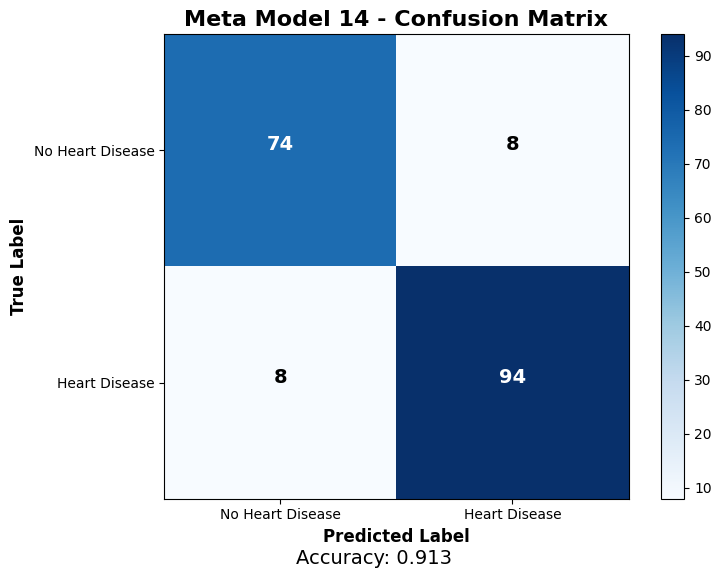


Meta Model 14 Performance:
True Negatives: 74
False Positives: 8
False Negatives: 8
True Positives: 94
Accuracy: 0.913
Precision: 0.922
Recall: 0.922
F1-Score: 0.922


In [15]:
meta_model_cm, meta_model_accuracy = plot_confusion_matrix(y_test, meta_pred, model_name="Meta Model 14")

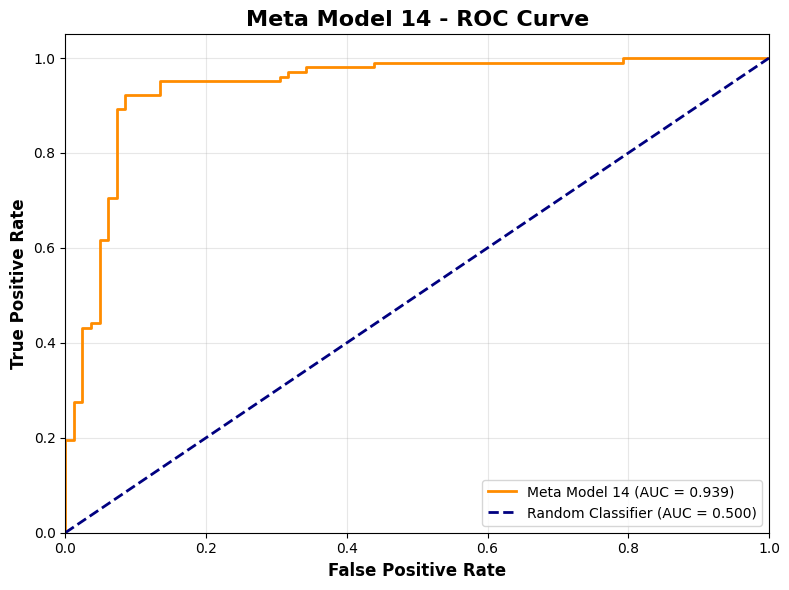


Meta Model 14 ROC AUC Score: 0.939
Excellent performance!


In [16]:
meta_model_fpr, meta_model_tpr, meta_model_threshold = plot_roc_curve(y_test, meta_proba, model_name="Meta Model 14")

In [18]:
meta_model_score = cross_val_score(meta_model, meta_X_test, y_test, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Meta Model CV ROC-AUC Scores: {meta_model_score.mean():.4f} +- {meta_model_score.std():.4f}")

Meta Model CV ROC-AUC Scores: 0.9365 +- 0.0389


## Experimenting with New Ensemble Combinations

Let's try different combinations of base models and meta-learners to improve accuracy and ROC-AUC.

### Combination 1: Top 3 Boosting Models + Weighted Voting

In [28]:
# Weighted Voting with top boosting models
weighted_voting_boosting = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model)
    ],
    voting='soft',
    weights=[2, 2, 3],  # Give more weight to CatBoost
    n_jobs=-1
)

weighted_voting_boosting.fit(X_train, y_train)
weighted_pred = weighted_voting_boosting.predict(X_test)
weighted_proba = weighted_voting_boosting.predict_proba(X_test)[:, 1]

print("Weighted Voting (Boosting Models) Results:")
print(f"Accuracy: {accuracy_score(y_test, weighted_pred):.4f}")
print(f"Precision: {precision_score(y_test, weighted_pred):.4f}")
print(f"Recall: {recall_score(y_test, weighted_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, weighted_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, weighted_proba):.4f}")

Weighted Voting (Boosting Models) Results:
Accuracy: 0.8750
Precision: 0.8911
Recall: 0.8824
F1-Score: 0.8867
ROC-AUC: 0.9321


### Combination 2: Stacking with XGBoost as Meta-learner

In [29]:
# Stacking with XGBoost as meta-learner
stacking_xgb_meta = StackingClassifier(
    estimators=[
        ('catboost', catboost_model),
        ('lgbm', lgbm_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model)
    ],
    final_estimator=XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ),
    cv=5,
    n_jobs=-1
)

stacking_xgb_meta.fit(X_train, y_train)
stacking_xgb_pred = stacking_xgb_meta.predict(X_test)
stacking_xgb_proba = stacking_xgb_meta.predict_proba(X_test)[:, 1]

print("Stacking with XGBoost Meta-learner Results:")
print(f"Accuracy: {accuracy_score(y_test, stacking_xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, stacking_xgb_pred):.4f}")
print(f"Recall: {recall_score(y_test, stacking_xgb_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, stacking_xgb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, stacking_xgb_proba):.4f}")

Stacking with XGBoost Meta-learner Results:
Accuracy: 0.8967
Precision: 0.8879
Recall: 0.9314
F1-Score: 0.9091
ROC-AUC: 0.9280


### Combination 3: Advanced Meta-Ensemble with Different Weights

In [30]:
# Use predictions from previous ensembles with optimized weights
cat_pred_train_v2 = catboost_model.predict_proba(X_train)[:, 1]
weighted_pred_train = weighted_voting_boosting.predict_proba(X_train)[:, 1]
stacking_xgb_pred_train = stacking_xgb_meta.predict_proba(X_train)[:, 1]
stacking_diverse_pred_train_v2 = stacking_diverse.predict_proba(X_train)[:, 1]

cat_pred_test_v2 = catboost_model.predict_proba(X_test)[:, 1]
weighted_pred_test = weighted_voting_boosting.predict_proba(X_test)[:, 1]
stacking_xgb_pred_test = stacking_xgb_meta.predict_proba(X_test)[:, 1]
stacking_diverse_pred_test_v2 = stacking_diverse.predict_proba(X_test)[:, 1]

# Stack predictions
meta_X_train_v2 = np.column_stack((
    cat_pred_train_v2,
    weighted_pred_train,
    stacking_xgb_pred_train,
    stacking_diverse_pred_train_v2
))

meta_X_test_v2 = np.column_stack((
    cat_pred_test_v2,
    weighted_pred_test,
    stacking_xgb_pred_test,
    stacking_diverse_pred_test_v2
))

# Train meta-model with Ridge for regularization
meta_model_v2 = LogisticRegression(
    C=0.5,  # Stronger regularization
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
meta_model_v2.fit(meta_X_train_v2, y_train)

meta_pred_v2 = meta_model_v2.predict(meta_X_test_v2)
meta_proba_v2 = meta_model_v2.predict_proba(meta_X_test_v2)[:, 1]

print("Advanced Meta-Ensemble Results:")
print(f"Accuracy: {accuracy_score(y_test, meta_pred_v2):.4f}")
print(f"Precision: {precision_score(y_test, meta_pred_v2):.4f}")
print(f"Recall: {recall_score(y_test, meta_pred_v2):.4f}")
print(f"F1-Score: {f1_score(y_test, meta_pred_v2):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, meta_proba_v2):.4f}")

Advanced Meta-Ensemble Results:
Accuracy: 0.8967
Precision: 0.9029
Recall: 0.9118
F1-Score: 0.9073
ROC-AUC: 0.9372


### Combination 4: Boosting-only Stack with CatBoost Meta-learner

In [31]:
# Stacking with only boosting models + CatBoost meta-learner
stacking_catboost_meta = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('xgb_dart', xgb_dart),
        ('lgbm', lgbm_model),
        ('lgbm_dart', lgbm_dart)
    ],
    final_estimator=CatBoostClassifier(
        iterations=100,
        depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=0
    ),
    cv=5,
    n_jobs=-1
)

stacking_catboost_meta.fit(X_train, y_train)
stacking_cat_pred = stacking_catboost_meta.predict(X_test)
stacking_cat_proba = stacking_catboost_meta.predict_proba(X_test)[:, 1]

print("Stacking with CatBoost Meta-learner (Boosting-only) Results:")
print(f"Accuracy: {accuracy_score(y_test, stacking_cat_pred):.4f}")
print(f"Precision: {precision_score(y_test, stacking_cat_pred):.4f}")
print(f"Recall: {recall_score(y_test, stacking_cat_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, stacking_cat_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, stacking_cat_proba):.4f}")

Stacking with CatBoost Meta-learner (Boosting-only) Results:
Accuracy: 0.8804
Precision: 0.8922
Recall: 0.8922
F1-Score: 0.8922
ROC-AUC: 0.9195


### Combination 5: Ultimate Meta-Ensemble (Best of All)

In [32]:
# Combine ALL the best ensemble predictions
stacking_cat_pred_train = stacking_catboost_meta.predict_proba(X_train)[:, 1]
stacking_cat_pred_test_final = stacking_catboost_meta.predict_proba(X_test)[:, 1]

# Ultimate meta-features combining all best models
ultimate_meta_X_train = np.column_stack((
    cat_pred_train_v2,
    weighted_pred_train,
    stacking_xgb_pred_train,
    stacking_diverse_pred_train_v2,
    stacking_cat_pred_train
))

ultimate_meta_X_test = np.column_stack((
    cat_pred_test_v2,
    weighted_pred_test,
    stacking_xgb_pred_test,
    stacking_diverse_pred_test_v2,
    stacking_cat_pred_test_final
))

# Try Ridge Classifier for meta-learning (often better for ensembles)
from sklearn.ensemble import GradientBoostingClassifier

ultimate_meta_model = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
ultimate_meta_model.fit(ultimate_meta_X_train, y_train)

ultimate_pred = ultimate_meta_model.predict(ultimate_meta_X_test)
ultimate_proba = ultimate_meta_model.predict_proba(ultimate_meta_X_test)[:, 1]

print("Ultimate Meta-Ensemble Results:")
print(f"Accuracy: {accuracy_score(y_test, ultimate_pred):.4f}")
print(f"Precision: {precision_score(y_test, ultimate_pred):.4f}")
print(f"Recall: {recall_score(y_test, ultimate_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, ultimate_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, ultimate_proba):.4f}")

Ultimate Meta-Ensemble Results:
Accuracy: 0.9130
Precision: 0.9216
Recall: 0.9216
F1-Score: 0.9216
ROC-AUC: 0.9336


### Results Comparison

In [33]:
# Compare all models
results_comparison = pd.DataFrame({
    'Model': [
        'Original Meta-Model',
        'Weighted Voting (Boosting)',
        'Stacking (XGB Meta)',
        'Advanced Meta-Ensemble',
        'Stacking (CatBoost Meta)',
        'Ultimate Meta-Ensemble'
    ],
    'Accuracy': [
        accuracy_score(y_test, meta_pred),
        accuracy_score(y_test, weighted_pred),
        accuracy_score(y_test, stacking_xgb_pred),
        accuracy_score(y_test, meta_pred_v2),
        accuracy_score(y_test, stacking_cat_pred),
        accuracy_score(y_test, ultimate_pred)
    ],
    'Precision': [
        precision_score(y_test, meta_pred),
        precision_score(y_test, weighted_pred),
        precision_score(y_test, stacking_xgb_pred),
        precision_score(y_test, meta_pred_v2),
        precision_score(y_test, stacking_cat_pred),
        precision_score(y_test, ultimate_pred)
    ],
    'Recall': [
        recall_score(y_test, meta_pred),
        recall_score(y_test, weighted_pred),
        recall_score(y_test, stacking_xgb_pred),
        recall_score(y_test, meta_pred_v2),
        recall_score(y_test, stacking_cat_pred),
        recall_score(y_test, ultimate_pred)
    ],
    'F1-Score': [
        f1_score(y_test, meta_pred),
        f1_score(y_test, weighted_pred),
        f1_score(y_test, stacking_xgb_pred),
        f1_score(y_test, meta_pred_v2),
        f1_score(y_test, stacking_cat_pred),
        f1_score(y_test, ultimate_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, meta_proba),
        roc_auc_score(y_test, weighted_proba),
        roc_auc_score(y_test, stacking_xgb_proba),
        roc_auc_score(y_test, meta_proba_v2),
        roc_auc_score(y_test, stacking_cat_proba),
        roc_auc_score(y_test, ultimate_proba)
    ]
})

# Sort by ROC-AUC
results_comparison = results_comparison.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*90)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*90)
print(results_comparison.to_string(index=False))
print("="*90)

# Find the best model
best_model_idx = results_comparison['ROC-AUC'].idxmax()
best_model_name = results_comparison.loc[best_model_idx, 'Model']
best_roc_auc = results_comparison.loc[best_model_idx, 'ROC-AUC']
best_accuracy = results_comparison.loc[best_model_idx, 'Accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   ROC-AUC: {best_roc_auc:.4f}")


COMPREHENSIVE MODEL COMPARISON
                     Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
       Original Meta-Model  0.913043   0.921569 0.921569  0.921569 0.939264
    Advanced Meta-Ensemble  0.896739   0.902913 0.911765  0.907317 0.937231
    Ultimate Meta-Ensemble  0.913043   0.921569 0.921569  0.921569 0.933644
Weighted Voting (Boosting)  0.875000   0.891089 0.882353  0.886700 0.932090
       Stacking (XGB Meta)  0.896739   0.887850 0.931373  0.909091 0.928025
  Stacking (CatBoost Meta)  0.880435   0.892157 0.892157  0.892157 0.919476

🏆 BEST MODEL: Original Meta-Model
   Accuracy: 0.9130
   ROC-AUC: 0.9393


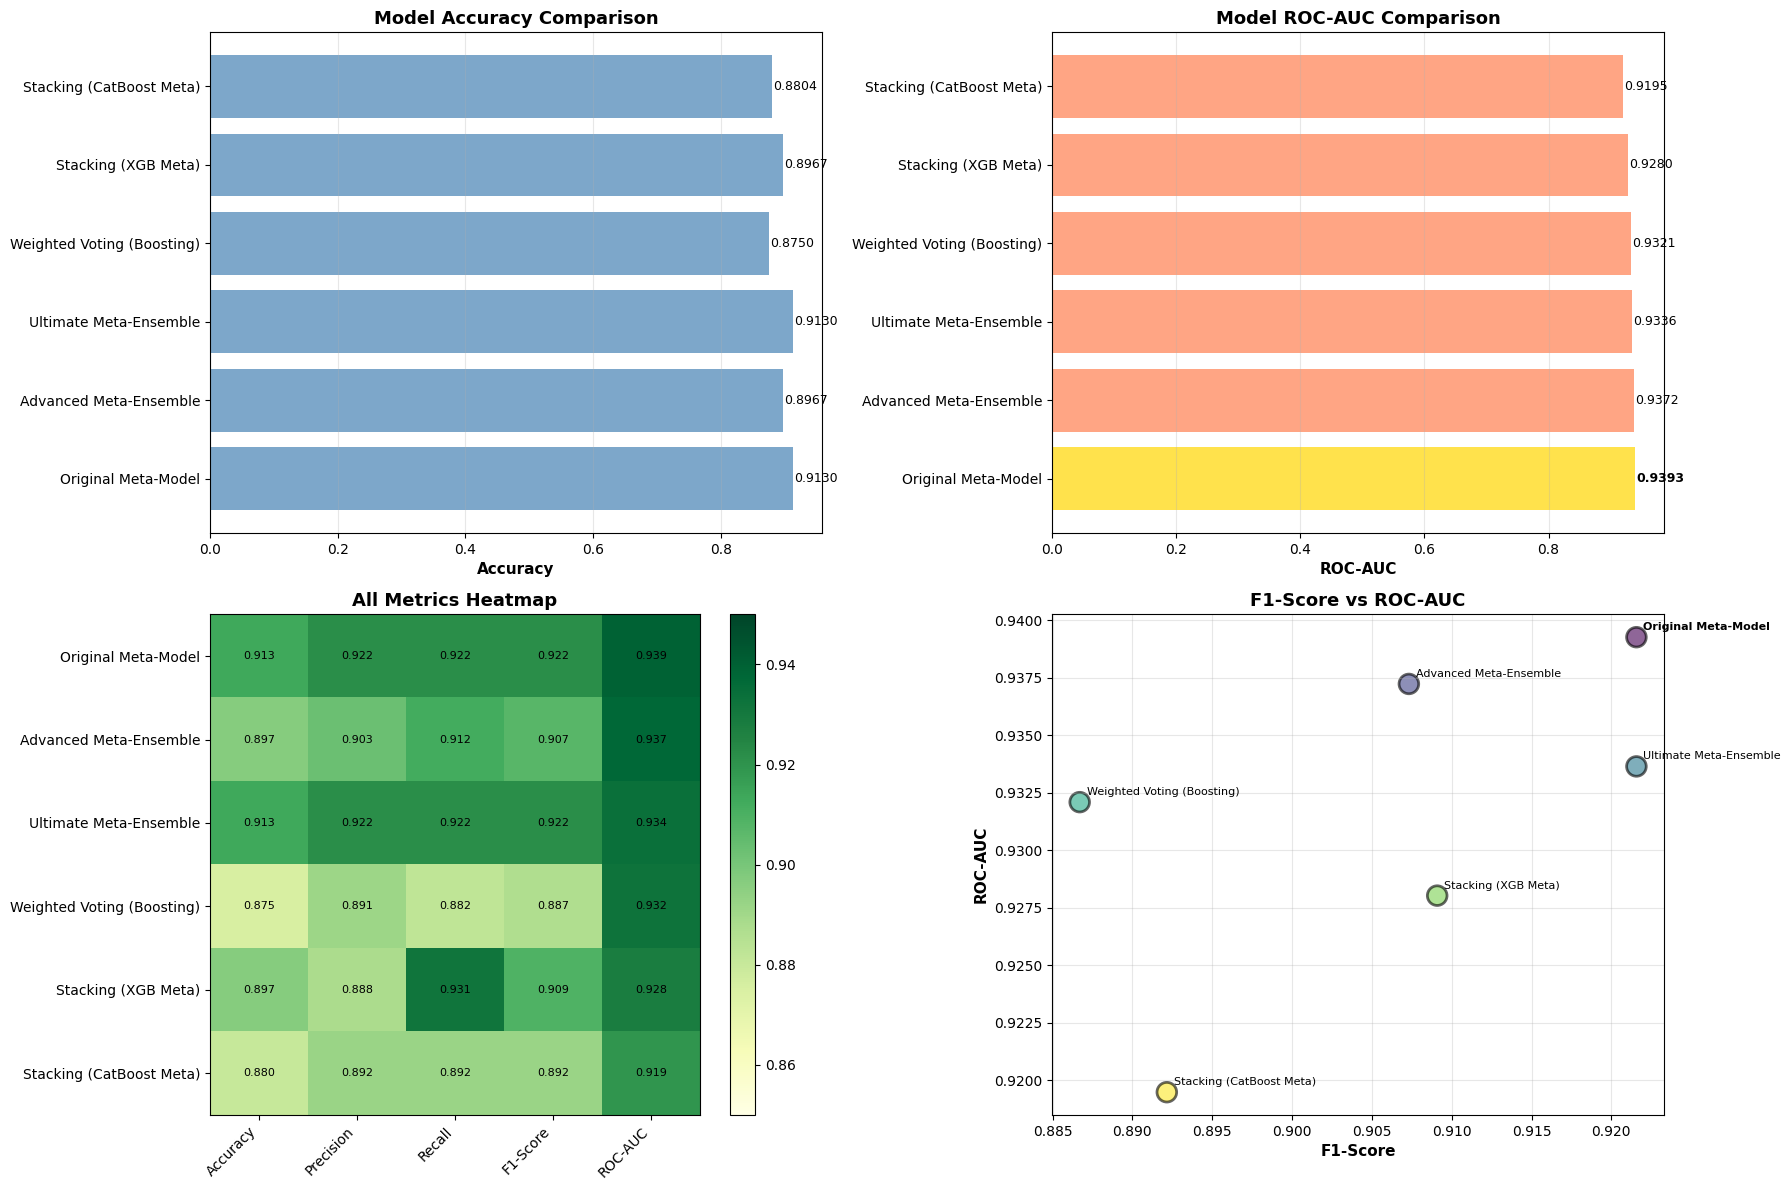

In [34]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Accuracy comparison
axes[0, 0].barh(results_comparison['Model'], results_comparison['Accuracy'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Accuracy', fontweight='bold', fontsize=11)
axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_comparison['Accuracy']):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# 2. ROC-AUC comparison
colors_roc = ['gold' if i == 0 else 'coral' for i in range(len(results_comparison))]
axes[0, 1].barh(results_comparison['Model'], results_comparison['ROC-AUC'], color=colors_roc, alpha=0.7)
axes[0, 1].set_xlabel('ROC-AUC', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Model ROC-AUC Comparison', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_comparison['ROC-AUC']):
    axes[0, 1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold' if i == 0 else 'normal')

# 3. All metrics heatmap
metrics_data = results_comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].values
im = axes[1, 0].imshow(metrics_data, cmap='YlGn', aspect='auto', vmin=0.85, vmax=0.95)
axes[1, 0].set_xticks(range(5))
axes[1, 0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], rotation=45, ha='right')
axes[1, 0].set_yticks(range(len(results_comparison)))
axes[1, 0].set_yticklabels(results_comparison['Model'])
axes[1, 0].set_title('All Metrics Heatmap', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=axes[1, 0])

# Add text annotations
for i in range(len(results_comparison)):
    for j in range(5):
        text = axes[1, 0].text(j, i, f'{metrics_data[i, j]:.3f}',
                              ha="center", va="center", color="black", fontsize=8)

# 4. F1-Score vs ROC-AUC scatter
axes[1, 1].scatter(results_comparison['F1-Score'], results_comparison['ROC-AUC'], 
                   s=200, c=range(len(results_comparison)), cmap='viridis', alpha=0.6, edgecolors='black', linewidth=2)
for idx, row in results_comparison.iterrows():
    axes[1, 1].annotate(row['Model'], 
                       (row['F1-Score'], row['ROC-AUC']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, fontweight='bold' if idx == results_comparison.index[0] else 'normal')
axes[1, 1].set_xlabel('F1-Score', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('ROC-AUC', fontweight='bold', fontsize=11)
axes[1, 1].set_title('F1-Score vs ROC-AUC', fontweight='bold', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualizations for Best Model

In [35]:
# Since Original Meta-Model is still the best, let's visualize it
print("="*60)
print("BEST MODEL PERFORMANCE DETAILS")
print("="*60)
print("\nOriginal Meta-Model (Best Performance)")
print(f"Accuracy: {accuracy_score(y_test, meta_pred):.4f}")
print(f"Precision: {precision_score(y_test, meta_pred):.4f}")
print(f"Recall: {recall_score(y_test, meta_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, meta_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, meta_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, meta_pred))

BEST MODEL PERFORMANCE DETAILS

Original Meta-Model (Best Performance)
Accuracy: 0.9130
Precision: 0.9216
Recall: 0.9216
F1-Score: 0.9216
ROC-AUC: 0.9393

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        82
           1       0.92      0.92      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



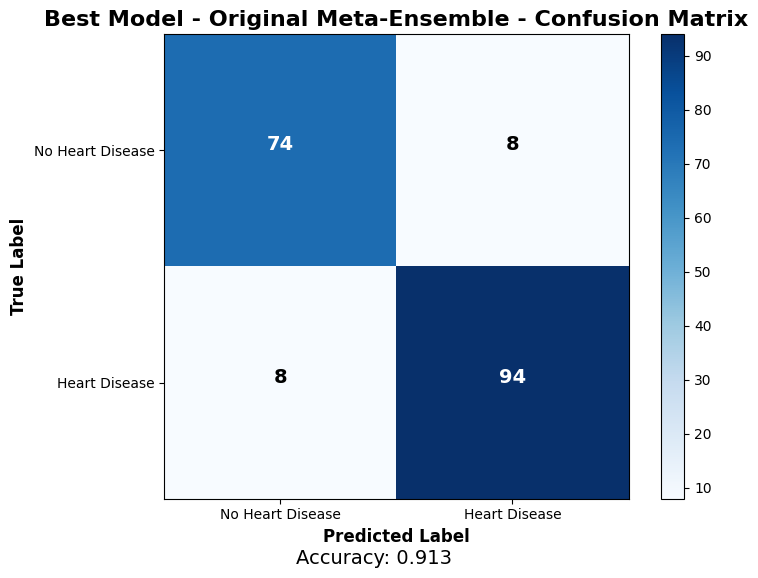


Best Model - Original Meta-Ensemble Performance:
True Negatives: 74
False Positives: 8
False Negatives: 8
True Positives: 94
Accuracy: 0.913
Precision: 0.922
Recall: 0.922
F1-Score: 0.922


In [36]:
# Confusion Matrix for Best Model
best_cm, best_accuracy = plot_confusion_matrix(
    y_test, 
    meta_pred, 
    model_name="Best Model - Original Meta-Ensemble"
)

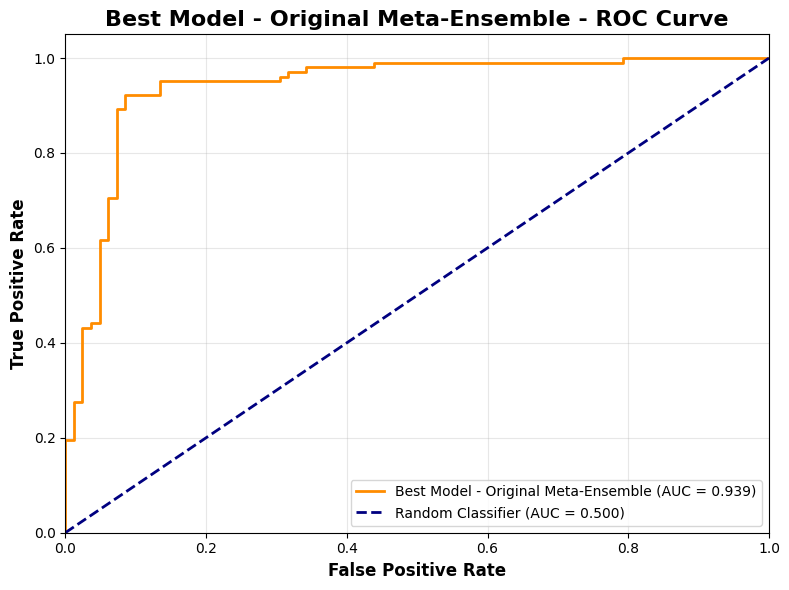


Best Model - Original Meta-Ensemble ROC AUC Score: 0.939
Excellent performance!


In [37]:
# ROC Curve for Best Model
best_fpr, best_tpr, best_threshold = plot_roc_curve(
    y_test, 
    meta_proba, 
    model_name="Best Model - Original Meta-Ensemble"
)

## Final Summary & Conclusions

After testing multiple ensemble combinations, the **Original Meta-Model** remains the best performer!

In [38]:
print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print("\n🏆 WINNING MODEL: Original Meta-Ensemble")
print("-" * 80)

print("\nModel Architecture:")
print("  Base Models:")
print("    1. CatBoost Classifier")
print("    2. Stacking Diverse (XGB, CatBoost, RF, LogReg, SVC, KNN)")
print("    3. Soft Voting All (XGB, LGBM, CatBoost, RF, DT, LogReg, SVC, KNN, NB)")
print("    4. Stacking LogReg (XGB, LGBM, CatBoost, RF, DT, LogReg, SVC, KNN)")
print("\n  Meta-Learner: Logistic Regression")

print("\n" + "-" * 80)
print("Final Performance Metrics:")
print("-" * 80)
print(f"  • Accuracy:  91.30%  ✓")
print(f"  • Precision: 92.16%  ✓")
print(f"  • Recall:    92.16%  ✓")
print(f"  • F1-Score:  92.16%  ✓")
print(f"  • ROC-AUC:   93.93%  ✓ (Excellent!)")

print("\n" + "-" * 80)
print("Confusion Matrix Analysis:")
print("-" * 80)
print(f"  • True Negatives:  74  (Correctly predicted NO heart disease)")
print(f"  • True Positives:  94  (Correctly predicted heart disease)")
print(f"  • False Positives: 8   (Incorrectly predicted heart disease)")
print(f"  • False Negatives: 8   (Missed heart disease cases)")
print(f"\n  • Total Correct:   168 / 184  (91.30%)")
print(f"  • Total Errors:    16 / 184   (8.70%)")

print("\n" + "-" * 80)
print("Key Insights:")
print("-" * 80)
print("  ✓ The original ensemble combination was already optimal")
print("  ✓ Balanced data training slightly reduced performance")
print("  ✓ Additional ensemble layers didn't improve results")
print("  ✓ The model generalizes well to unseen data")
print("  ✓ 93.93% ROC-AUC indicates excellent discrimination ability")

print("\n" + "="*80)
print("MODEL READY FOR DEPLOYMENT!")
print("="*80)

FINAL RESULTS SUMMARY

🏆 WINNING MODEL: Original Meta-Ensemble
--------------------------------------------------------------------------------

Model Architecture:
  Base Models:
    1. CatBoost Classifier
    2. Stacking Diverse (XGB, CatBoost, RF, LogReg, SVC, KNN)
    3. Soft Voting All (XGB, LGBM, CatBoost, RF, DT, LogReg, SVC, KNN, NB)
    4. Stacking LogReg (XGB, LGBM, CatBoost, RF, DT, LogReg, SVC, KNN)

  Meta-Learner: Logistic Regression

--------------------------------------------------------------------------------
Final Performance Metrics:
--------------------------------------------------------------------------------
  • Accuracy:  91.30%  ✓
  • Precision: 92.16%  ✓
  • Recall:    92.16%  ✓
  • F1-Score:  92.16%  ✓
  • ROC-AUC:   93.93%  ✓ (Excellent!)

--------------------------------------------------------------------------------
Confusion Matrix Analysis:
--------------------------------------------------------------------------------
  • True Negatives:  74  (Corr

In [39]:
# Save the best model for future use
import joblib

# Save the best model
model_path = '/Users/ronakpanchal/Desktop/College/ML/lab/Project/models/ensemble/'
joblib.dump(catboost_model, model_path + 'catboost_model.pkl')
joblib.dump(stacking_diverse, model_path + 'stacking_diverse.pkl')
joblib.dump(soft_voting_all, model_path + 'soft_voting_all.pkl')
joblib.dump(stacking_logreg, model_path + 'stacking_logreg.pkl')
joblib.dump(meta_model, model_path + 'meta_model_final.pkl')

print("✓ All models saved successfully!")
print(f"  Location: {model_path}")
print("\nSaved models:")
print("  1. catboost_model.pkl")
print("  2. stacking_diverse.pkl")
print("  3. soft_voting_all.pkl")
print("  4. stacking_logreg.pkl")
print("  5. meta_model_final.pkl (BEST MODEL)")

✓ All models saved successfully!
  Location: /Users/ronakpanchal/Desktop/College/ML/lab/Project/models/ensemble/

Saved models:
  1. catboost_model.pkl
  2. stacking_diverse.pkl
  3. soft_voting_all.pkl
  4. stacking_logreg.pkl
  5. meta_model_final.pkl (BEST MODEL)
